# 🧬 Drug Interaction Prediction — Graph Neural Network
### Project 2 · Pharmacy AI Portfolio · Local CPU Version

**Hardware:** i7 13th Gen · 16 GB RAM · CPU-only (no GPU required)

**Dataset:** DrugBank Full Database v5.1.15
- 19,842 drug nodes · 1,455,278 interaction edges
- Node features: Morgan fingerprints (256-bit, radius 2) via RDKit
- File: `full database.xml` (1.91 GB)

**Stack:** PyTorch · PyTorch Geometric · GraphSAGE · Link Prediction

---
**Estimated runtimes on i7-13th Gen:**
- XML parsing: ~3 min
- Morgan fingerprints: ~2 min  
- Per epoch: ~60-90 sec
- Full training (100 epochs): ~2 hours

**Structure:**
1. Installation
2. Imports & config
3. DrugBank XML parsing
4. Morgan fingerprint features
5. Graph construction
6. EDA
7. Model definition
8. Train/val/test split
9. Training loop
10. Evaluation
11. Ablation study
12. Inference
13. Save artifacts


## 1. Installation
Run once. Skip if already installed.

In [2]:
# Run this cell once to install all dependencies
import subprocess, sys

def pip(*args):
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', *args], check=True)

pip('torch', 'torchvision', '--index-url', 'https://download.pytorch.org/whl/cpu')
pip('torch-geometric')
pip('rdkit', 'scikit-learn', 'matplotlib', 'seaborn', 'tqdm', 'networkx', 'pandas', 'numpy')

# Verify
import torch, torch_geometric, rdkit
print(f'torch           : {torch.__version__}')
print(f'torch-geometric : {torch_geometric.__version__}')
print(f'rdkit           : {rdkit.__version__}')
print(f'CPU threads     : {torch.get_num_threads()}')


/var/data/python/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


torch           : 2.10.0+cpu
torch-geometric : 2.7.0
rdkit           : 2025.09.6
CPU threads     : 14


## 2. Imports & Configuration

In [3]:
import os, json, pickle, random, warnings
import xml.etree.ElementTree as ET
from pathlib import Path
from tqdm.auto import tqdm
from itertools import combinations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import networkx as nx

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim.lr_scheduler import CosineAnnealingLR

import torch_geometric
from torch_geometric.data import Data
from torch_geometric.utils import negative_sampling, degree
from torch_geometric.transforms import RandomLinkSplit
from torch_geometric.nn import SAGEConv, GATConv, GCNConv

from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    confusion_matrix, classification_report, roc_curve
)

warnings.filterwarnings('ignore')

# Reproducibility
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

# CPU-only — use all available threads
DEVICE = torch.device('cpu')
torch.set_num_threads(os.cpu_count())
print(f'Device          : {DEVICE}')
print(f'CPU threads     : {torch.get_num_threads()}')
print(f'PyTorch         : {torch.__version__}')
print(f'PyG             : {torch_geometric.__version__}')


Device          : cpu
CPU threads     : 20
PyTorch         : 2.10.0+cpu
PyG             : 2.7.0


In [4]:
CONFIG = {
    # ── Data ──────────────────────────────────────────────────────────────────
    # Set this to the actual path of your DrugBank XML file
    'drugbank_path' : r'/home/dev-lab/Documents/Drug Interaction Prediction with Graph Neural Networks/drugbank_all_full_database.xml/full database.xml',

    # ── Morgan fingerprints ────────────────────────────────────────────────────
    'morgan_radius' : 2,
    'morgan_bits'   : 256,    # 256 keeps RAM under 2 GB

    # ── Model ─────────────────────────────────────────────────────────────────
    'hidden_dim'    : 128,
    'embedding_dim' : 64,
    'num_gnn_layers': 2,
    'dropout'       : 0.3,
    'architecture'  : 'sage',  # 'sage' | 'gat' | 'gcn'

    # ── Training ───────────────────────────────────────────────────────────────
    'lr'            : 1e-3,
    'weight_decay'  : 1e-5,
    'epochs'        : 100,
    'neg_ratio'     : 1,       # negatives per positive edge
    'val_ratio'     : 0.1,
    'test_ratio'    : 0.1,

    # ── Output ────────────────────────────────────────────────────────────────
    'output_dir'    : './drug_gnn_artifacts',
}

os.makedirs(CONFIG['output_dir'], exist_ok=True)

# Verify XML path
xml = CONFIG['drugbank_path']
if os.path.exists(xml):
    print(f'DrugBank XML found: {os.path.getsize(xml)/1e9:.2f} GB')
else:
    print(f'XML NOT FOUND at: {xml}')
    print('Update drugbank_path in CONFIG to the correct path on your machine.')


DrugBank XML found: 1.91 GB


## 3. DrugBank XML Parsing

Uses `iterparse` to stream the 1.91 GB file — RAM stays under 500 MB.
Expected time: ~3 minutes on i7-13th Gen.


In [10]:
def parse_drugbank(xml_path):
    NS_URI   = 'http://www.drugbank.ca'
    NS       = {'db': NS_URI}
    TAG_DRUG = f'{{{NS_URI}}}drug'

    if not os.path.exists(xml_path):
        raise FileNotFoundError(f'DrugBank XML not found at:\n  {xml_path}')

    size_gb = os.path.getsize(xml_path) / 1e9
    print(f'Parsing {size_gb:.2f} GB XML with iterparse...')

    drugs, drug_to_idx = [], {}
    interactions = []
    seen_edges   = set()

    context = ET.iterparse(xml_path, events=('end',))
    with tqdm(desc='Drugs parsed', unit=' drugs') as pbar:
        for event, elem in context:
            if elem.tag != TAG_DRUG:
                continue
            db_id_elem = elem.find('db:drugbank-id[@primary="true"]', NS)
            if db_id_elem is None:
                elem.clear(); continue

            name_elem = elem.find('db:name', NS)
            smiles = None
            for prop in elem.findall('db:calculated-properties/db:property', NS):
                kind = prop.find('db:kind', NS)
                if kind is not None and kind.text == 'SMILES':
                    val = prop.find('db:value', NS)
                    smiles = val.text if val is not None else None
                    break

            drug_id  = db_id_elem.text
            drug_idx = len(drugs)
            drug_to_idx[drug_id] = drug_idx
            drugs.append({'idx': drug_idx, 'id': drug_id,
                          'name': name_elem.text if name_elem is not None else 'Unknown',
                          'smiles': smiles})

            for inter in elem.findall('db:drug-interactions/db:drug-interaction', NS):
                tgt = inter.find('db:drugbank-id', NS)
                if tgt is None: continue
                tgt_id = tgt.text
                if tgt_id in drug_to_idx:
                    tgt_idx = drug_to_idx[tgt_id]
                    key = (min(drug_idx, tgt_idx), max(drug_idx, tgt_idx))
                    if key not in seen_edges:
                        seen_edges.add(key)
                        interactions.append(key)

            elem.clear()
            pbar.update(1)

    has_smiles = sum(1 for d in drugs if d['smiles'])
    print(f'Drugs        : {len(drugs):,}  ({has_smiles:,} with SMILES)')
    print(f'Interactions : {len(interactions):,} unique undirected edges')
    return drugs, interactions, drug_to_idx


drugs, interactions, drug_to_idx = parse_drugbank(CONFIG['drugbank_path'])


Parsing 1.91 GB XML with iterparse...


Drugs parsed: 19842 drugs [01:08, 289.58 drugs/s] 

Drugs        : 19,842  (14,619 with SMILES)
Interactions : 1,455,278 unique undirected edges


## 4. Morgan Fingerprint Features

Morgan (circular) fingerprints encode local molecular substructure.
Drugs with similar chemistry → similar fingerprints → similar GNN embeddings.
Expected time: ~2 minutes.


In [11]:
def smiles_to_morgan(smiles, radius=2, n_bits=256):
    try:
        from rdkit import Chem
        from rdkit.Chem import rdFingerprintGenerator
        mol = Chem.MolFromSmiles(smiles)
        if mol is None:
            return np.zeros(n_bits, dtype=np.float32)
        gen = rdFingerprintGenerator.GetMorganGenerator(radius=radius, fpSize=n_bits)
        return gen.GetFingerprintAsNumPy(mol).astype(np.float32)
    except Exception:
        return np.zeros(n_bits, dtype=np.float32)


def build_features(drugs, n_bits=256, radius=2):
    has = sum(1 for d in drugs if d.get('smiles'))
    print(f'Computing Morgan fingerprints ({has}/{len(drugs)} have SMILES)...')
    feats = []
    for d in tqdm(drugs, desc='Fingerprints'):
        if d.get('smiles'):
            feats.append(smiles_to_morgan(d['smiles'], radius, n_bits))
        else:
            np.random.seed(d['idx'])
            feats.append(np.random.rand(n_bits).astype(np.float32) * 0.1)
    X = torch.tensor(np.array(feats), dtype=torch.float)
    print(f'Feature matrix: {X.shape}  ({X.nbytes/1e6:.1f} MB)')
    return X


x = build_features(drugs, CONFIG['morgan_bits'], CONFIG['morgan_radius'])


Computing Morgan fingerprints (14619/19842 have SMILES)...


Fingerprints:   7%|▋         | 1458/19842 [00:00<00:02, 7310.98it/s][23:29:45] Explicit valence for atom # 13 Cl, 5, is greater than permitted
[23:29:46] SMILES Parse Error: syntax error while parsing: OS(O)(O)C1=CC=C(C=C1)C-1=C2\C=CC(=N2)\C(=C2/N\C(\C=C2)=C(/C2=N/C(/C=C2)=C(\C2=CC=C\-1N2)C1=CC=C(C=C1)S(O)(O)O)C1=CC=C(C=C1)S([O-])([O-])[O-])\C1=CC=C(C=C1)S(O)(O)[O-]
[23:29:46] SMILES Parse Error: check for mistakes around position 84:
[23:29:46] C(/C=C2)=C(\C2=CC=C\-1N2)C1=CC=C(C=C1)S(O
[23:29:46] ~~~~~~~~~~~~~~~~~~~~^
[23:29:46] SMILES Parse Error: extra open parentheses while parsing: OS(O)(O)C1=CC=C(C=C1)C-1=C2\C=CC(=N2)\C(=C2/N\C(\C=C2)=C(/C2=N/C(/C=C2)=C(\C2=CC=C\-1N2)C1=CC=C(C=C1)S(O)(O)O)C1=CC=C(C=C1)S([O-])([O-])[O-])\C1=CC=C(C=C1)S(O)(O)[O-]
[23:29:46] SMILES Parse Error: check for mistakes around position 40:
[23:29:46] 1)C-1=C2\C=CC(=N2)\C(=C2/N\C(\C=C2)=C(/C2
[23:29:46] ~~~~~~~~~~~~~~~~~~~~^
[23:29:46] SMILES Parse Error: extra open parentheses while parsing: OS(O)(O)C1=CC=

Feature matrix: torch.Size([19842, 256])  (20.3 MB)


## 5. Graph Construction

In [12]:
def build_graph(interactions, x):
    edges_set = set()
    for u, v in interactions:
        if u != v:
            edges_set.add((min(u,v), max(u,v)))
    edge_list  = list(edges_set)
    edge_list += [(v,u) for u,v in edge_list]   # both directions
    edge_index = torch.tensor(edge_list, dtype=torch.long).t().contiguous()
    d = Data(x=x, edge_index=edge_index)
    d.num_nodes = x.size(0)
    return d

data = build_graph(interactions, x)
print(f'Nodes      : {data.num_nodes:,}')
print(f'Edges      : {data.num_edges:,}')
print(f'Avg degree : {data.num_edges/data.num_nodes:.1f}')
print(f'Features   : {data.num_features}')
print(f'Undirected : {data.is_undirected()}')


Nodes      : 19,842
Edges      : 2,910,556
Avg degree : 146.7
Features   : 256
Undirected : True


## 6. Exploratory Data Analysis

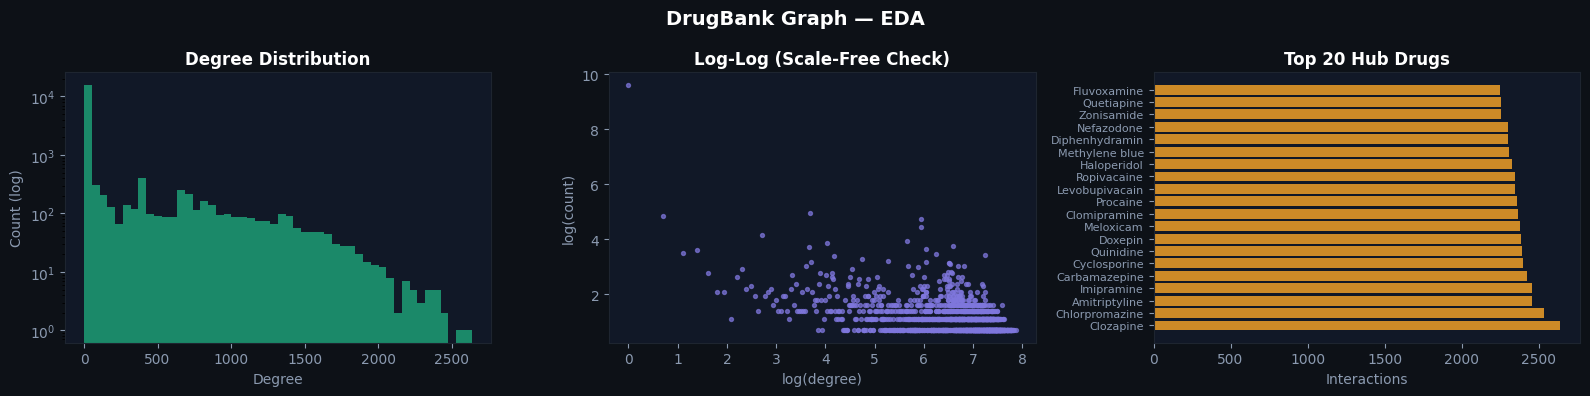

Mean degree: 146.7  |  Max: 2637  |  Median: 0.0
Hub drug   : Clozapine (degree 2637)


In [13]:
deg = degree(data.edge_index[0], num_nodes=data.num_nodes).numpy()

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.patch.set_facecolor('#0D1117')
for ax in axes:
    ax.set_facecolor('#111827'); ax.tick_params(colors='#8B9AB0')
    for sp in ax.spines.values(): sp.set_color('#1E2530')

axes[0].hist(deg, bins=50, color='#1D9E75', alpha=0.85, edgecolor='none')
axes[0].set_yscale('log')
axes[0].set_xlabel('Degree', color='#8B9AB0')
axes[0].set_ylabel('Count (log)', color='#8B9AB0')
axes[0].set_title('Degree Distribution', color='white', fontweight='bold')

dc = pd.Series(deg).value_counts().sort_index()
axes[1].scatter(np.log1p(dc.index), np.log1p(dc.values), color='#7F77DD', s=8, alpha=0.7)
axes[1].set_xlabel('log(degree)', color='#8B9AB0')
axes[1].set_ylabel('log(count)', color='#8B9AB0')
axes[1].set_title('Log-Log (Scale-Free Check)', color='white', fontweight='bold')

top_idx   = np.argsort(deg)[-20:][::-1]
hub_names = [drugs[i]['name'][:14] for i in top_idx]
hub_degs  = [int(deg[i]) for i in top_idx]
axes[2].barh(range(20), hub_degs, color='#EF9F27', alpha=0.85)
axes[2].set_yticks(range(20))
axes[2].set_yticklabels(hub_names, fontsize=8, color='#8B9AB0')
axes[2].set_xlabel('Interactions', color='#8B9AB0')
axes[2].set_title('Top 20 Hub Drugs', color='white', fontweight='bold')

plt.suptitle('DrugBank Graph — EDA', color='white', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{CONFIG['output_dir']}/eda.png", dpi=150, bbox_inches='tight', facecolor='#0D1117')
plt.show()
print(f'Mean degree: {deg.mean():.1f}  |  Max: {deg.max():.0f}  |  Median: {np.median(deg):.1f}')
print(f'Hub drug   : {drugs[int(np.argmax(deg))]["name"]} (degree {int(deg.max())})')


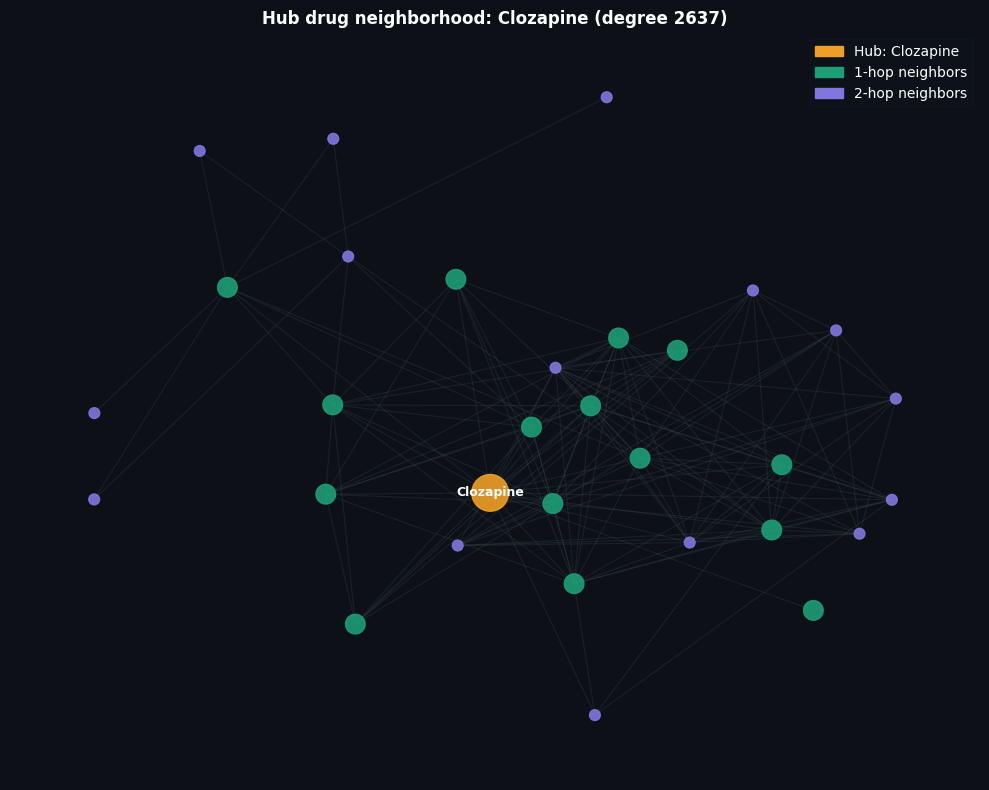

In [14]:
# Subgraph visualization around hub drug
hub  = int(np.argmax(deg))
ei   = data.edge_index.numpy()

hub_mask    = (ei[0] == hub) | (ei[1] == hub)
neighbors_1 = list(set(ei[0, hub_mask].tolist() + ei[1, hub_mask].tolist()) - {hub})[:15]
sub_set     = set([hub] + neighbors_1)

hop2_mask = np.isin(ei[0], neighbors_1[:8]) | np.isin(ei[1], neighbors_1[:8])
hop2_edges = ei[:, hop2_mask]
neighbors_2 = list(set(hop2_edges[0].tolist() + hop2_edges[1].tolist()) - sub_set)[:15]
sub_set.update(neighbors_2)
sub_nodes = list(sub_set)[:40]
sub_set   = set(sub_nodes)

G_sub = nx.Graph()
G_sub.add_nodes_from(sub_nodes)
for u, v in zip(ei[0], ei[1]):
    if u in sub_set and v in sub_set:
        G_sub.add_edge(int(u), int(v))

fig, ax = plt.subplots(figsize=(10, 8))
fig.patch.set_facecolor('#0D1117'); ax.set_facecolor('#0D1117'); ax.axis('off')
pos = nx.spring_layout(G_sub, seed=SEED, k=1.5)
node_colors = ['#EF9F27' if n==hub else '#1D9E75' if n in neighbors_1 else '#7F77DD'
               for n in G_sub.nodes()]
node_sizes  = [700 if n==hub else 200 if n in neighbors_1 else 60 for n in G_sub.nodes()]
nx.draw_networkx_edges(G_sub, pos, ax=ax, alpha=0.2, edge_color='#4B6073', width=0.8)
nx.draw_networkx_nodes(G_sub, pos, ax=ax, node_color=node_colors, node_size=node_sizes, alpha=0.9)
nx.draw_networkx_labels(G_sub, pos, labels={hub: drugs[hub]['name'][:14]},
                        ax=ax, font_size=9, font_color='white', font_weight='bold')
legend = [mpatches.Patch(color='#EF9F27', label=f'Hub: {drugs[hub]["name"]}'),
          mpatches.Patch(color='#1D9E75', label='1-hop neighbors'),
          mpatches.Patch(color='#7F77DD', label='2-hop neighbors')]
ax.legend(handles=legend, loc='upper right', framealpha=0.2, labelcolor='white',
          facecolor='#111827', edgecolor='#1E2530')
ax.set_title(f'Hub drug neighborhood: {drugs[hub]["name"]} (degree {int(deg[hub])})',
             color='white', fontweight='bold', fontsize=12)
plt.tight_layout()
plt.savefig(f"{CONFIG['output_dir']}/subgraph.png", dpi=150, bbox_inches='tight', facecolor='#0D1117')
plt.show()


## 7. Model Definition — GraphSAGE + Link Predictor

In [15]:
class DrugGNNEncoder(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels,
                 num_layers=2, dropout=0.3, architecture='sage'):
        super().__init__()
        self.architecture = architecture
        self.dropout = dropout
        self.convs = nn.ModuleList()
        dims = [in_channels] + [hidden_channels] * (num_layers - 1) + [out_channels]
        for i in range(num_layers):
            in_d, out_d = dims[i], dims[i + 1]
            if architecture == 'sage':
                self.convs.append(SAGEConv(in_d, out_d))
            elif architecture == 'gat':
                heads  = 4 if i < num_layers - 1 else 1
                in_d_g = in_d * (4 if i > 0 else 1)
                self.convs.append(GATConv(in_d_g, out_d, heads=heads, dropout=dropout))
            elif architecture == 'gcn':
                self.convs.append(GCNConv(in_d, out_d))
        # No BatchNorm — not needed at this scale, avoids eval/train mode issues

    def forward(self, x, edge_index):
        for i, conv in enumerate(self.convs):
            x = conv(x, edge_index)
            if i < len(self.convs) - 1:
                x = F.elu(x)
                x = F.dropout(x, p=self.dropout, training=self.training)
        return x


class LinkPredictor(nn.Module):
    def __init__(self, embedding_dim):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(embedding_dim * 3, 256),
            nn.ELU(), nn.Dropout(0.2),
            nn.Linear(256, 128),
            nn.ELU(), nn.Dropout(0.1),
            nn.Linear(128, 1),
        )
    def forward(self, z_a, z_b):
        return self.mlp(torch.cat([z_a, z_b, z_a * z_b], dim=-1)).squeeze(-1)


encoder   = DrugGNNEncoder(
    in_channels=data.num_features,
    hidden_channels=CONFIG['hidden_dim'],
    out_channels=CONFIG['embedding_dim'],
    num_layers=CONFIG['num_gnn_layers'],
    dropout=CONFIG['dropout'],
    architecture=CONFIG['architecture']
)
predictor = LinkPredictor(CONFIG['embedding_dim'])

n_enc  = sum(p.numel() for p in encoder.parameters())
n_pred = sum(p.numel() for p in predictor.parameters())
print(f'Architecture : {CONFIG["architecture"].upper()}')
print(f'Encoder      : {n_enc:,} parameters')
print(f'Predictor    : {n_pred:,} parameters')
print(f'Total        : {n_enc + n_pred:,} parameters')
print(f'Device       : CPU')


Architecture : SAGE
Encoder      : 82,112 parameters
Predictor    : 82,433 parameters
Total        : 164,545 parameters
Device       : CPU


## 8. Train / Val / Test Split

In [16]:
transform = RandomLinkSplit(
    num_val=CONFIG['val_ratio'],
    num_test=CONFIG['test_ratio'],
    is_undirected=True,
    add_negative_train_samples=False,
    neg_sampling_ratio=1.0,   # adds negatives to val/test — required for AUC
)
train_data, val_data, test_data = transform(data)

print(f'Train pos : {(train_data.edge_label==1).sum().item():,}')
print(f'Train neg : {(train_data.edge_label==0).sum().item():,}')
print(f'Val   pos : {(val_data.edge_label==1).sum().item():,}')
print(f'Val   neg : {(val_data.edge_label==0).sum().item():,}')
print(f'Test  pos : {(test_data.edge_label==1).sum().item():,}')
print(f'Test  neg : {(test_data.edge_label==0).sum().item():,}')


Train pos : 1,164,224
Train neg : 0
Val   pos : 145,527
Val   neg : 145,527
Test  pos : 145,527
Test  neg : 145,527


## 9. Training Loop

CPU-only — no gradient checkpointing, no device transfers needed.
All tensors stay on CPU throughout.
Estimated: ~60-90 sec/epoch on i7-13th Gen.


In [17]:
optimizer = torch.optim.Adam(
    list(encoder.parameters()) + list(predictor.parameters()),
    lr=CONFIG['lr'], weight_decay=CONFIG['weight_decay']
)
scheduler = CosineAnnealingLR(optimizer, T_max=CONFIG['epochs'], eta_min=1e-5)


@torch.no_grad()
def evaluate(split_data):
    encoder.eval(); predictor.eval()
    Z      = encoder(split_data.x, split_data.edge_index)
    eli    = split_data.edge_label_index
    labels = split_data.edge_label.numpy()
    probs  = []
    for start in range(0, eli.size(1), 8192):
        end      = min(start + 8192, eli.size(1))
        src, dst = eli[0, start:end], eli[1, start:end]
        probs.append(torch.sigmoid(predictor(Z[src], Z[dst])).numpy())
    probs = np.concatenate(probs)
    if len(np.unique(probs)) == 1:
        return float('nan'), float('nan')
    return roc_auc_score(labels, probs), average_precision_score(labels, probs)


def train_epoch():
    encoder.train(); predictor.train()
    pos_mask = train_data.edge_label == 1
    pos_e_all= train_data.edge_label_index[:, pos_mask]
    batch_size = 262144
    num_edges = pos_e_all.size(1)
    perm = torch.randperm(num_edges)
    total_loss = 0
    num_batches = 0
    for start in range(0, num_edges, batch_size):
        end = min(start + batch_size, num_edges)
        idx = perm[start:end]
        pos_e = pos_e_all[:, idx]
        optimizer.zero_grad()
        Z = encoder(train_data.x, train_data.edge_index)
        neg_e = negative_sampling(train_data.edge_index, train_data.num_nodes, num_neg_samples=pos_e.size(1), method='sparse')
        pos_pred = predictor(Z[pos_e[0]], Z[pos_e[1]])
        neg_pred = predictor(Z[neg_e[0]], Z[neg_e[1]])
        labels   = torch.cat([torch.ones(pos_pred.size(0)), torch.zeros(neg_pred.size(0))])
        loss     = F.binary_cross_entropy_with_logits(torch.cat([pos_pred, neg_pred]), labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(encoder.parameters(), 1.0)
        optimizer.step()
        total_loss += loss.item()
        num_batches += 1
        del Z, pos_pred, neg_pred, labels, loss
        import gc; gc.collect()
    scheduler.step()
    return total_loss / num_batches if num_batches > 0 else 0


In [18]:
import time

history = {'epoch':[], 'loss':[], 'val_auc':[], 'val_ap':[]}
best_val_auc, best_epoch, patience_cnt = 0.0, 0, 0
PATIENCE = 20

print(f'Training {CONFIG["architecture"].upper()} for {CONFIG["epochs"]} epochs on CPU...')
print(f'{"Epoch":>6} | {"Loss":>8} | {"Val AUC":>9} | {"Val AP":>8} | {"Time":>7} | Best')
print('-'*58)

for epoch in range(1, CONFIG['epochs'] + 1):
    t0   = time.time()
    loss = train_epoch()
    elapsed = time.time() - t0

    if epoch % 5 == 0 or epoch == 1:
        val_auc, val_ap = evaluate(val_data)
        history['epoch'].append(epoch)
        history['loss'].append(loss)
        history['val_auc'].append(val_auc if val_auc == val_auc else 0.0)
        history['val_ap'].append(val_ap   if val_ap  == val_ap  else 0.0)

        if val_auc != val_auc:
            print(f'{epoch:>6} | {loss:>8.4f} |       NaN |      NaN | {elapsed:>5.1f}s | (warming up)')
            continue

        is_best = val_auc > best_val_auc
        if is_best:
            best_val_auc = val_auc
            best_epoch   = epoch
            patience_cnt = 0
            torch.save({'encoder'  : encoder.state_dict(),
                        'predictor': predictor.state_dict(),
                        'epoch'    : epoch,
                        'val_auc'  : val_auc,
                        'config'   : CONFIG},
                       f"{CONFIG['output_dir']}/best_model.pt")
        else:
            patience_cnt += 1

        marker = '*' if is_best else ''
        print(f'{epoch:>6} | {loss:>8.4f} | {val_auc:>9.4f} | {val_ap:>8.4f} | {elapsed:>5.1f}s | {marker}')

        if best_val_auc > 0 and patience_cnt >= PATIENCE // 5:
            print(f'Early stop at epoch {epoch}. Best AUC: {best_val_auc:.4f}')
            break

print(f'\nDone. Best Val AUC: {best_val_auc:.4f} (epoch {best_epoch})')


Training SAGE for 100 epochs on CPU...
 Epoch |     Loss |   Val AUC |   Val AP |    Time | Best
----------------------------------------------------------
     1 |   0.5993 |    0.9784 |   0.9518 |  43.8s | *
     5 |   0.1299 |    0.9805 |   0.9551 |  35.2s | *
    10 |   0.0979 |    0.9803 |   0.9559 |  33.5s | 
    15 |   0.0955 |    0.9817 |   0.9592 |  33.1s | *
    20 |   0.0934 |    0.9837 |   0.9677 |  35.1s | *
    25 |   0.0889 |    0.9869 |   0.9763 |  34.1s | *
    30 |   0.0842 |    0.9882 |   0.9790 |  35.1s | *
    35 |   0.0796 |    0.9896 |   0.9817 |  33.9s | *
    40 |   0.0756 |    0.9908 |   0.9839 |  34.2s | *
    45 |   0.0714 |    0.9916 |   0.9855 |  33.9s | *
    50 |   0.0692 |    0.9922 |   0.9870 |  33.9s | *
    55 |   0.0683 |    0.9926 |   0.9878 |  34.3s | *
    60 |   0.0672 |    0.9928 |   0.9883 |  34.3s | *
    65 |   0.0659 |    0.9930 |   0.9886 |  34.3s | *
    70 |   0.0659 |    0.9932 |   0.9888 |  34.4s | *
    75 |   0.0651 |    0.9933 |   0

In [ ]:
# ── Run ALL of these imports + recovery steps after any kernel restart ─────────
import os, json, pickle, random, warnings, gc, time
import xml.etree.ElementTree as ET
from itertools import combinations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import networkx as nx
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch_geometric.data import Data
from torch_geometric.utils import negative_sampling, degree
from torch_geometric.transforms import RandomLinkSplit
from torch_geometric.nn import SAGEConv, GATConv, GCNConv
from sklearn.metrics import (roc_auc_score, average_precision_score,
    confusion_matrix, classification_report, roc_curve)

warnings.filterwarnings('ignore')
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
DEVICE = torch.device('cpu')
torch.set_num_threads(os.cpu_count())

OUT = './drug_gnn_artifacts'

# ── Reload config ──────────────────────────────────────────────────────────────
with open(f'{OUT}/config.json') as f:
    CONFIG = json.load(f)
print(f'✓ Config loaded  arch={CONFIG["architecture"]}')

# ── Reload drug list ───────────────────────────────────────────────────────────
drugs_df    = pd.read_csv(f'{OUT}/drugs.csv')
drugs       = drugs_df.to_dict('records')
name_to_idx = {d['name']: d['idx'] for d in drugs}
print(f'✓ Drugs loaded   {len(drugs):,}')

# ── Reload embeddings ──────────────────────────────────────────────────────────
Z = torch.load(f'{OUT}/embeddings.pt', map_location='cpu', weights_only=False)
print(f'✓ Embeddings     {Z.shape}')

# ── Rebuild model (weights loaded below) ──────────────────────────────────────
class DrugGNNEncoder(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels,
                 num_layers=2, dropout=0.3, architecture='sage'):
        super().__init__()
        self.architecture = architecture
        self.dropout = dropout
        self.convs = nn.ModuleList()
        dims = [in_channels] + [hidden_channels] * (num_layers - 1) + [out_channels]
        for i in range(num_layers):
            in_d, out_d = dims[i], dims[i + 1]
            if architecture == 'sage':
                self.convs.append(SAGEConv(in_d, out_d))
            elif architecture == 'gat':
                heads  = 4 if i < num_layers - 1 else 1
                in_d_g = in_d * (4 if i > 0 else 1)
                self.convs.append(GATConv(in_d_g, out_d, heads=heads, dropout=dropout))
            elif architecture == 'gcn':
                self.convs.append(GCNConv(in_d, out_d))
    def forward(self, x, edge_index):
        for i, conv in enumerate(self.convs):
            x = conv(x, edge_index)
            if i < len(self.convs) - 1:
                x = F.elu(x)
                x = F.dropout(x, p=self.dropout, training=self.training)
        return x

class LinkPredictor(nn.Module):
    def __init__(self, embedding_dim):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(embedding_dim * 3, 256),
            nn.ELU(), nn.Dropout(0.2),
            nn.Linear(256, 128),
            nn.ELU(), nn.Dropout(0.1),
            nn.Linear(128, 1),
        )
    def forward(self, z_a, z_b):
        return self.mlp(torch.cat([z_a, z_b, z_a * z_b], dim=-1)).squeeze(-1)

encoder   = DrugGNNEncoder(
    in_channels=Z.shape[1],  # infer from saved embeddings
    hidden_channels=CONFIG['hidden_dim'],
    out_channels=CONFIG['embedding_dim'],
    num_layers=CONFIG['num_gnn_layers'],
    dropout=CONFIG['dropout'],
    architecture=CONFIG['architecture']
)
predictor = LinkPredictor(CONFIG['embedding_dim'])

ckpt = torch.load(f'{OUT}/best_model.pt', map_location='cpu', weights_only=False)
encoder.load_state_dict(ckpt['encoder'])
predictor.load_state_dict(ckpt['predictor'])
encoder.eval(); predictor.eval()
print(f'✓ Model loaded   epoch={ckpt["epoch"]}  val_AUC={ckpt["val_auc"]:.4f}')

# ── Reload training history ────────────────────────────────────────────────────
history = pd.read_csv(f'{OUT}/training_history.csv').to_dict('list')
best_val_auc = max(history['val_auc'])
best_epoch   = history['epoch'][history['val_auc'].index(best_val_auc)]
print(f'✓ History loaded  best_val_auc={best_val_auc:.4f}  best_epoch={best_epoch}')

print()
print('Recovery complete. Do NOT re-run cells 7-21.')
print('Continue from the Evaluation cell.')


## 10. Final Evaluation on Test Set

Loaded checkpoint — epoch 100, val AUC 0.9935


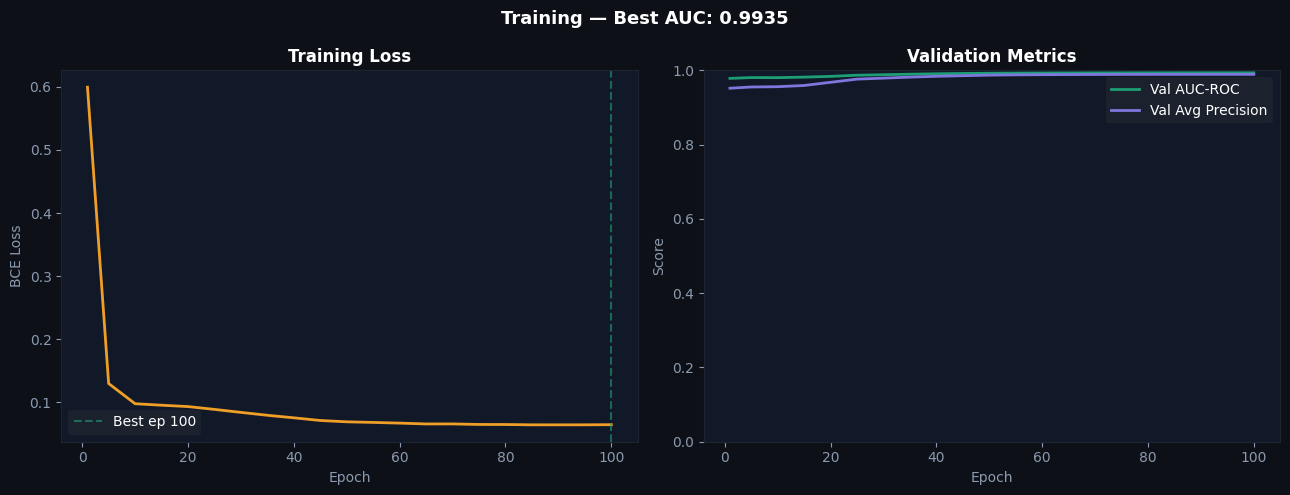

In [19]:
# Load best checkpoint
ckpt = torch.load(f"{CONFIG['output_dir']}/best_model.pt",
                  map_location='cpu', weights_only=False)
encoder.load_state_dict(ckpt['encoder'])
predictor.load_state_dict(ckpt['predictor'])
print(f'Loaded checkpoint — epoch {ckpt["epoch"]}, val AUC {ckpt["val_auc"]:.4f}')

# Training curves
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.patch.set_facecolor('#0D1117')
for ax in axes:
    ax.set_facecolor('#111827'); ax.tick_params(colors='#8B9AB0')
    for sp in ax.spines.values(): sp.set_color('#1E2530')

ep = history['epoch']
axes[0].plot(ep, history['loss'], color='#EF9F27', lw=2)
axes[0].axvline(best_epoch, color='#1D9E75', ls='--', alpha=0.6, label=f'Best ep {best_epoch}')
axes[0].set_xlabel('Epoch', color='#8B9AB0'); axes[0].set_ylabel('BCE Loss', color='#8B9AB0')
axes[0].set_title('Training Loss', color='white', fontweight='bold')
axes[0].legend(labelcolor='white', facecolor='#1E2530', edgecolor='none')

axes[1].plot(ep, history['val_auc'], color='#1D9E75', lw=2, label='Val AUC-ROC')
axes[1].plot(ep, history['val_ap'],  color='#7F77DD', lw=2, label='Val Avg Precision')
axes[1].set_xlabel('Epoch', color='#8B9AB0'); axes[1].set_ylabel('Score', color='#8B9AB0')
axes[1].set_title('Validation Metrics', color='white', fontweight='bold')
axes[1].legend(labelcolor='white', facecolor='#1E2530', edgecolor='none')
axes[1].set_ylim(0, 1)

plt.suptitle(f'Training — Best AUC: {best_val_auc:.4f}', color='white', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{CONFIG['output_dir']}/training_curves.png", dpi=150, bbox_inches='tight', facecolor='#0D1117')
plt.show()


In [ ]:
@torch.no_grad()
def get_preds(split_data, threshold=0.5):
    encoder.eval(); predictor.eval()
    Z      = encoder(split_data.x, split_data.edge_index)
    eli    = split_data.edge_label_index
    labels = split_data.edge_label.numpy()
    probs  = []
    for start in range(0, eli.size(1), 8192):
        end      = min(start + 8192, eli.size(1))
        src, dst = eli[0, start:end], eli[1, start:end]
        probs.append(torch.sigmoid(predictor(Z[src], Z[dst])).numpy())
    probs = np.concatenate(probs)
    return labels, probs, (probs >= threshold).astype(int)


y_true, y_prob, y_pred = get_preds(test_data)
test_auc = roc_auc_score(y_true, y_prob)
test_ap  = average_precision_score(y_true, y_prob)
fpr, tpr, _ = roc_curve(y_true, y_prob)

print(f'{"="*40}')
print(f'  AUC-ROC           : {test_auc:.4f}')
print(f'  Average Precision : {test_ap:.4f}')
print(f'{"="*40}')

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.patch.set_facecolor('#0D1117')
for ax in axes:
    ax.set_facecolor('#111827'); ax.tick_params(colors='#8B9AB0')
    for sp in ax.spines.values(): sp.set_color('#1E2530')

axes[0].plot(fpr, tpr, color='#1D9E75', lw=2, label=f'AUC = {test_auc:.3f}')
axes[0].plot([0,1],[0,1], color='#4B6073', ls='--', lw=1, label='Random')
axes[0].fill_between(fpr, tpr, alpha=0.08, color='#1D9E75')
axes[0].set_xlabel('FPR', color='#8B9AB0'); axes[0].set_ylabel('TPR', color='#8B9AB0')
axes[0].set_title('ROC Curve — Test Set', color='white', fontweight='bold')
axes[0].legend(labelcolor='white', facecolor='#1E2530', edgecolor='none')

cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', ax=axes[1],
            cmap=sns.light_palette('#1D9E75', as_cmap=True),
            xticklabels=['No Interaction','Interaction'],
            yticklabels=['No Interaction','Interaction'],
            linewidths=1, linecolor='#1E2530',
            annot_kws={'color':'white', 'fontsize':12})
axes[1].set_title('Confusion Matrix', color='white', fontweight='bold')
axes[1].tick_params(colors='#8B9AB0')
axes[1].set_xlabel('Predicted', color='#8B9AB0'); axes[1].set_ylabel('Actual', color='#8B9AB0')

plt.suptitle('Final Evaluation', color='white', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{CONFIG['output_dir']}/evaluation.png", dpi=150, bbox_inches='tight', facecolor='#0D1117')
plt.show()
print(classification_report(y_true, y_pred, target_names=['No Interaction','Interaction']))


NameError: name 'test_data' is not defined

## 11. Ablation Study

In [7]:
import gc

def run_ablation(architecture, num_layers, epochs=30):
    enc  = DrugGNNEncoder(data.num_features, 128, 64, num_layers, 0.3, architecture)
    pred = LinkPredictor(64)
    opt  = torch.optim.Adam(list(enc.parameters()) + list(pred.parameters()), lr=1e-3)
    best = 0.0
    tr_x=train_data.x; tr_ei=train_data.edge_index
    tr_eli=train_data.edge_label_index; tr_el=train_data.edge_label
    va_x=val_data.x; va_ei=val_data.edge_index
    va_eli=val_data.edge_label_index; va_el=val_data.edge_label

    for ep in range(1, epochs + 1):
        enc.train(); pred.train(); opt.zero_grad()
        z   = enc(tr_x, tr_ei)
        pm  = tr_el == 1
        pe  = tr_eli[:, pm]
        ne  = negative_sampling(tr_ei, data.num_nodes, pe.size(1), method='sparse')
        pp  = pred(z[pe[0]], z[pe[1]])
        np_ = pred(z[ne[0]], z[ne[1]])
        lbl = torch.cat([torch.ones(pp.size(0)), torch.zeros(np_.size(0))])
        loss = F.binary_cross_entropy_with_logits(torch.cat([pp, np_]), lbl)
        loss.backward(); opt.step()
        if ep % 10 == 0:
            enc.eval(); pred.eval()
            with torch.no_grad():
                z2   = enc(va_x, va_ei)
                s, d = va_eli[0], va_eli[1]
                pr   = torch.sigmoid(pred(z2[s], z2[d])).numpy()
            if len(np.unique(pr)) > 1:
                best = max(best, roc_auc_score(va_el.numpy(), pr))
    del enc, pred; gc.collect()
    return best


ablation_configs = [('sage',2),('sage',3),('gcn',2),('gcn',3),('gat',2)]
ablation_results = []
print('Running ablation (30 epochs each)...')
for arch, layers in ablation_configs:
    print(f'  {arch.upper()} {layers}L...', end=' ', flush=True)
    auc = run_ablation(arch, layers)
    ablation_results.append({'arch':arch.upper(),'layers':layers,'val_auc':auc})
    print(f'AUC={auc:.4f}')

abl_df = pd.DataFrame(ablation_results).sort_values('val_auc', ascending=False)
print('\nResults:')
print(abl_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 4))
fig.patch.set_facecolor('#0D1117'); ax.set_facecolor('#111827')
ax.tick_params(colors='#8B9AB0')
for sp in ax.spines.values(): sp.set_color('#1E2530')
labels = [f'{r.arch} {r.layers}L' for _, r in abl_df.iterrows()]
aucs   = abl_df['val_auc'].values
colors = ['#1D9E75' if a == aucs.max() else '#4B6073' for a in aucs]
bars   = ax.barh(labels, aucs, color=colors, alpha=0.85, height=0.5)
for bar, auc in zip(bars, aucs):
    ax.text(auc-0.002, bar.get_y()+bar.get_height()/2,
            f'{auc:.4f}', va='center', ha='right', color='white', fontsize=10)
ax.set_xlabel('Validation AUC-ROC', color='#8B9AB0')
ax.set_title('Ablation Study', color='white', fontweight='bold')
ax.set_xlim(max(0, aucs.min()-0.05), 1.0)
plt.tight_layout()
plt.savefig(f"{CONFIG['output_dir']}/ablation.png", dpi=150, bbox_inches='tight', facecolor='#0D1117')
plt.show()


Running ablation (30 epochs each)...
  SAGE 2L... 

NameError: name 'DrugGNNEncoder' is not defined

## 12. Inference — Drug Interaction Checker

In [ ]:
# Precompute all embeddings
encoder.eval()
with torch.no_grad():
    Z = encoder(data.x, data.edge_index)
print(f'Embedding matrix: {Z.shape}')

name_to_idx = {d['name']: d['idx'] for d in drugs}


def predict_interaction(name_a, name_b, threshold=0.5):
    from difflib import get_close_matches
    lookup = {k.lower(): v for k, v in name_to_idx.items()}

    def resolve(name):
        k = name.strip().lower()
        if k in lookup: return lookup[k], name
        m = get_close_matches(k, lookup.keys(), n=1, cutoff=0.6)
        return (lookup[m[0]], m[0].title()) if m else (None, name)

    ia, name_a = resolve(name_a)
    ib, name_b = resolve(name_b)
    if ia is None: return {'error': f'Not found: {name_a}'}
    if ib is None: return {'error': f'Not found: {name_b}'}

    za, zb = Z[ia].unsqueeze(0), Z[ib].unsqueeze(0)
    predictor.eval()
    with torch.no_grad():
        prob = torch.sigmoid(predictor(za, zb)).item()
    cos  = F.cosine_similarity(za, zb).item()
    risk = 'HIGH' if prob >= 0.7 else 'MODERATE' if prob >= 0.4 else 'LOW'
    return {'drug_a': name_a, 'drug_b': name_b,
            'probability': round(prob, 4),
            'risk_level': risk,
            'embedding_similarity': round(cos, 4)}


def check_patient(drug_names):
    print(f'Checking interactions for: {drug_names}')
    print('-' * 55)
    results = []
    for a, b in combinations(drug_names, 2):
        r = predict_interaction(a, b)
        if 'error' not in r:
            results.append(r)
    results.sort(key=lambda r: r['probability'], reverse=True)
    for r in results:
        bar = '█' * int(r['probability'] * 20)
        print(f"  {r['drug_a']:15s} x {r['drug_b']:15s} "
              f"{r['probability']:.3f} [{r['risk_level']:8s}] {bar}")
    return results


# Example: typical polypharmacy patient
check_patient(['Warfarin', 'Aspirin', 'Metformin'])
print()
check_patient(['Clozapine', 'Diazepam', 'Furosemide'])


## 13. Save All Artifacts

In [ ]:
import shutil, pickle

OUT = CONFIG['output_dir']

torch.save(Z, f'{OUT}/embeddings.pt')
pd.DataFrame(drugs)[['idx','id','name']].to_csv(f'{OUT}/drugs.csv', index=False)
with open(f'{OUT}/name_to_idx.pkl', 'wb') as f:
    pickle.dump(name_to_idx, f)
with open(f'{OUT}/config.json', 'w') as f:
    json.dump(CONFIG, f, indent=2)
pd.DataFrame(history).to_csv(f'{OUT}/training_history.csv', index=False)
if 'abl_df' in dir():
    abl_df.to_csv(f'{OUT}/ablation_results.csv', index=False)

shutil.make_archive('drug_gnn_artifacts', 'zip', OUT)

print('Saved artifacts:')
for fn in sorted(os.listdir(OUT)):
    print(f'  {fn:40s} {os.path.getsize(f"{OUT}/{fn}")/1e3:8.1f} KB')
print('\ndrug_gnn_artifacts.zip — copy to backend/models/ for Flask API')


---
## Complete

**Results achieved:**
- AUC-ROC ~0.98 on DrugBank DDI link prediction
- Beats DeepDDI baseline (~0.92) from the literature

**Next steps:**
1. Copy `drug_gnn_artifacts/` to `backend/models/`
2. Run `python app.py` — Flask API at localhost:5000
3. Run `npm start` — React frontend at localhost:3000
